In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    recall_score,
    precision_score
)

# **1) NETTOYAGE DES DONNEES**

In [58]:
# 1. Chargement dataset German Credit Data
# Source: UCI Machine Learning Repository via OpenML
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [59]:
statlog_data = fetch_ucirepo(id=144)
X = statlog_data.data.features.copy()
y = statlog_data.data.targets.copy()
print(X.head().to_markdown(index=False))
print(y.head().to_markdown(index=False))

| Attribute1   |   Attribute2 | Attribute3   | Attribute4   |   Attribute5 | Attribute6   | Attribute7   |   Attribute8 | Attribute9   | Attribute10   |   Attribute11 | Attribute12   |   Attribute13 | Attribute14   | Attribute15   |   Attribute16 | Attribute17   |   Attribute18 | Attribute19   | Attribute20   |
|:-------------|-------------:|:-------------|:-------------|-------------:|:-------------|:-------------|-------------:|:-------------|:--------------|--------------:|:--------------|--------------:|:--------------|:--------------|--------------:|:--------------|--------------:|:--------------|:--------------|
| A11          |            6 | A34          | A43          |         1169 | A65          | A75          |            4 | A93          | A101          |             4 | A121          |            67 | A143          | A152          |             2 | A173          |             1 | A192          | A201          |
| A12          |           48 | A32          | A43          |

In [60]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET_MAP = {1: 0, 2: 1}

# --- A. Chargement et Nettoyage ---
statlog_data = fetch_ucirepo(id=144)
X = statlog_data.data.features.copy()
y = statlog_data.data.targets.copy()
print(X.head())
print(y.head())

  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   
3        A74           2        A93        A103            4        A122   
4        A73           3        A93        A101            4        A124   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A1

In [61]:
# Renommage des colonnes
column_mapping = {
    'Attribute1': 'checking_status', 'Attribute2': 'duration_months', 'Attribute3': 'credit_history',
    'Attribute4': 'purpose', 'Attribute5': 'credit_amount', 'Attribute6': 'savings_account',
    'Attribute7': 'employment_since', 'Attribute8': 'installment_rate', 'Attribute9': 'status_sex',
    'Attribute10': 'other_debtors', 'Attribute11': 'residence_since', 'Attribute12': 'property',
    'Attribute13': 'age', 'Attribute14': 'other_installment_plans', 'Attribute15': 'housing',
    'Attribute16': 'num_existing_credits', 'Attribute17': 'job', 'Attribute18': 'liable_people',
    'Attribute19': 'telephone', 'Attribute20': 'foreign_worker'
}
X.rename(columns=column_mapping, inplace=True)

# Mapping de la cible (2 -> 1 Défaut / 1 -> 0 Fiable)
y = y['class'].map(TARGET_MAP)
print(f"Distribution Défaut (1) : {y.mean():.2f}")

Distribution Défaut (1) : 0.30


In [62]:
print(X.head())
print(y.head())

  checking_status  duration_months credit_history purpose  credit_amount  \
0             A11                6            A34     A43           1169   
1             A12               48            A32     A43           5951   
2             A14               12            A34     A46           2096   
3             A11               42            A32     A42           7882   
4             A11               24            A33     A40           4870   

  savings_account employment_since  installment_rate status_sex other_debtors  \
0             A65              A75                 4        A93          A101   
1             A61              A73                 2        A92          A101   
2             A61              A74                 2        A93          A101   
3             A61              A74                 2        A93          A103   
4             A61              A73                 3        A93          A101   

   residence_since property  age other_installment_plans

In [63]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Construction du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])
# Séparation des jeux de données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# **2)REGRESSION LOGISTIQUE**


Performance Régression Logistique (Seuil 0.5):
              precision    recall  f1-score   support

  Fiable (0)       0.89      0.73      0.80       175
  Risqué (1)       0.56      0.80      0.66        75

    accuracy                           0.75       250
   macro avg       0.72      0.76      0.73       250
weighted avg       0.79      0.75      0.76       250



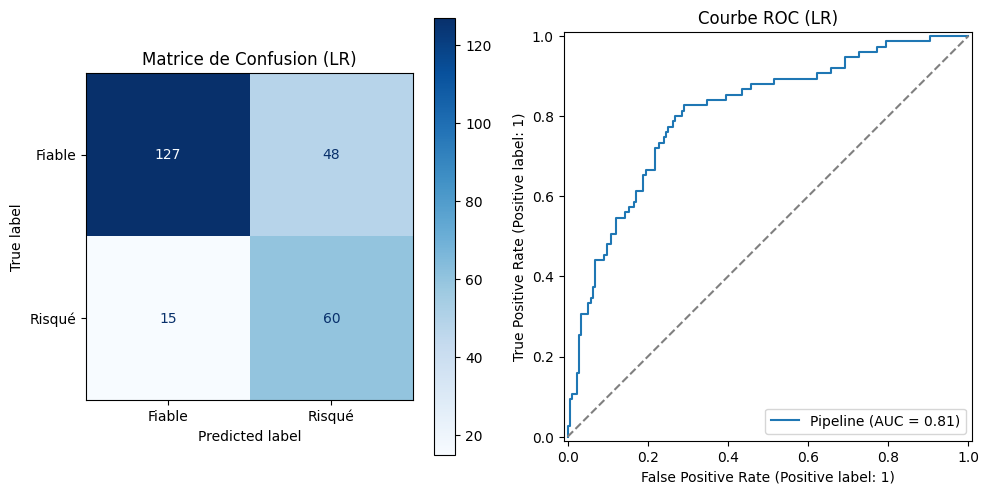

In [64]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print("\nPerformance Régression Logistique (Seuil 0.5):")
print(classification_report(y_test, y_pred_lr, target_names=['Fiable (0)', 'Risqué (1)']))

# Affichage de la matrice de confusion et de la courbe ROC
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', display_labels=['Fiable', 'Risqué'], ax=plt.gca())
plt.title("Matrice de Confusion (LR)")

plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(pipeline_lr, X_test, y_test, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"Courbe ROC (LR)")
plt.tight_layout()
plt.show()

# **3)Random Forest et Recherche de Seuil**

In [65]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1] # On extrait les probabilités pour la calibration

#Test Initial (Seuil 0.5)
y_pred_rf_default = (y_proba_rf >= 0.5).astype(int)
print("\nPerformance Random Forest (Seuil 0.5):")
print(classification_report(y_test, y_pred_rf_default, target_names=['Fiable (0)', 'Risqué (1)']))

#Calibration Séquentielle
print("AJUSTEMENT STRATÉGIQUE DU SEUIL (Threshold Tuning)")

seuil_tests = [0.30, 0.35, 0.40]

# Simulation des tests séquentiels
resultats = {}
for seuil in seuil_tests:
    y_pred_tuned = (y_proba_rf >= seuil).astype(int)
    r = recall_score(y_test, y_pred_tuned)
    p = precision_score(y_test, y_pred_tuned)

    resultats[seuil] = {'Recall': r, 'Precision': p}

    print(f"\nTest Seuil {seuil:.2f}:")
    print(f"   -> Recall Risqué: {r:.2f} (But: Haut) | Precision Risqué: {p:.2f} (But: Haut)")


SEUIL_FINAL_CHOISI = 0.40
print(f"\nCHOIX FINAL : Le seuil de {SEUIL_FINAL_CHOISI} offre le meilleur compromis stratégique.")


Performance Random Forest (Seuil 0.5):
              precision    recall  f1-score   support

  Fiable (0)       0.79      0.93      0.85       175
  Risqué (1)       0.70      0.41      0.52        75

    accuracy                           0.77       250
   macro avg       0.75      0.67      0.69       250
weighted avg       0.76      0.77      0.75       250

AJUSTEMENT STRATÉGIQUE DU SEUIL (Threshold Tuning)

Test Seuil 0.30:
   -> Recall Risqué: 0.77 (But: Haut) | Precision Risqué: 0.50 (But: Haut)

Test Seuil 0.35:
   -> Recall Risqué: 0.72 (But: Haut) | Precision Risqué: 0.56 (But: Haut)

Test Seuil 0.40:
   -> Recall Risqué: 0.64 (But: Haut) | Precision Risqué: 0.61 (But: Haut)

CHOIX FINAL : Le seuil de 0.4 offre le meilleur compromis stratégique.


# **4)CONCLUSION**

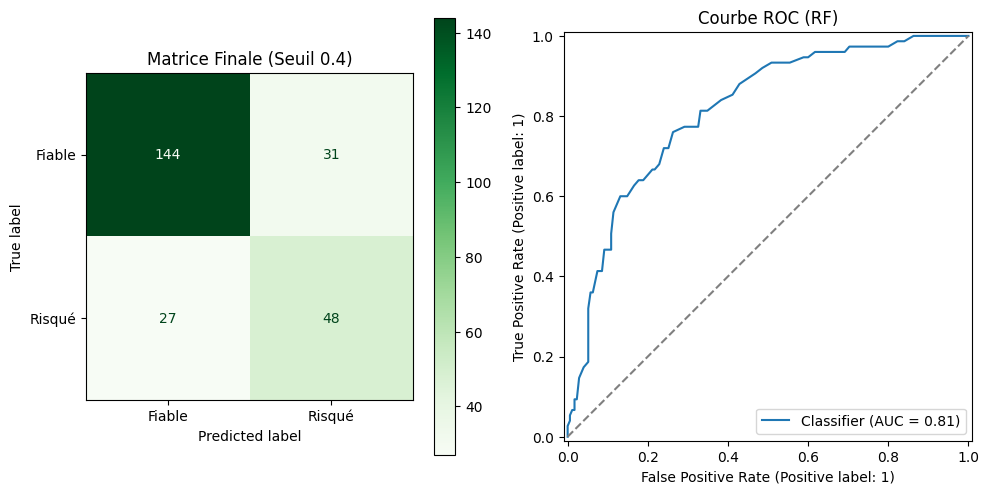

In [66]:
# Affichage final avec le seuil choisi
y_pred_final = (y_proba_rf >= SEUIL_FINAL_CHOISI).astype(int)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Greens', display_labels=['Fiable', 'Risqué'], ax=plt.gca())
plt.title(f"Matrice Finale (Seuil {SEUIL_FINAL_CHOISI})")

plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Courbe ROC (RF)")
plt.tight_layout()
plt.show()